<a href="https://colab.research.google.com/github/aishwarryaamm8/Aishwarryaa-MM---codeboosters---internship---2026/blob/main/DATA_ENG_DAY_2_CLASS_%2B_TASK_INTERNSHIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
#it is a plotting sub-model
import warnings
warnings.filterwarnings('ignore')
#suppresses non-critical warning messages that clutter output

print("All libraries imported successfully")
print(f"Pandas version : {pd.__version__}")
print(f"SQLite3 version : {sqlite3.version}")

All libraries imported successfully
Pandas version : 2.2.2
SQLite3 version : 2.6.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('student_performance.csv')

print(f"Dataset loaded : {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns : {df.columns.to_list()}")
print("\nFirst 3 rows : ")
df.head(3)


Dataset loaded : 30 students, 13 columns
Columns : ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows : 


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [4]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql('students', conn, if_exists='replace',index=False)

cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]

print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")

cursor.execute("PRAGMA table_info(students)")
columns_info = cursor.fetchall()

print("Table structure of 'students' : ")
print(f"{'Column Name':<25} {'Data Type':<12}")
print("-" * 30)

for col in columns_info:
    print(f"{col[0]:<25} {col[1]:<12}")

def run_query(sql, description=""):
    """Runs a SQL Query and returns the result as a pandas DataFrame.

    Parameters:
    -------------
    sql : str
        The SQL query string to execute.
    description : str
        A label to print above the result.
    """

    conn = sqlite3.connect("database.db")
    df = pd.read_sql_query(sql, conn)

    if description:
        print(description)

    conn.close()

    return df


Database 'college.db' created successfully!
Table 'students' has 30 rows
Table structure of 'students' : 
Column Name               Data Type   
------------------------------
0                         student_id  
1                         name        
2                         age         
3                         gender      
4                         department  
5                         semester    
6                         math_score  
7                         science_score
8                         english_score
9                         programming_score
10                        attendance_percentage
11                        city        
12                        admission_year


In [5]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
print(tables)


print(conn)

query = "SELECT * FROM students LIMIT 5"
df_check = pd.read_sql_query(query, conn)
print(df_check)

query = "PRAGMA table_info(students)"
columns = pd.read_sql_query(query, conn)

print(columns)

       name
0  students
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad   

In [6]:
def run_query(sql,description=""):
    if description:
        print(f"\n{'='*55}")
        print(f"{description}")
        print(f"{'='*55}")
    result = pd.read_sql_query(sql, conn)
    display(result)
    return result

print("Helper func. 'run query' defined successfully!")
print("usage: run_query(sql_string,description_label)")

Helper func. 'run query' defined successfully!
usage: run_query(sql_string,description_label)


In [7]:
query1 = """
  SELECT student_id,name,department,math_score,attendance_percentage
  FROM students
  LIMIT 10
"""
result1 = run_query(query1, "Query 1 : First 10 students)(SELECT * Limit)")


Query 1 : First 10 students)(SELECT * Limit)


,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [8]:
query2 = """
   select name,department,math_score
   from students
   order by math_score desc
   limit 5
"""
 #order by math_score  : sort by the math_score column
result2 = run_query(query2,"Query 2: Top 5 math scorers (order by desc + limit)")


Query 2: Top 5 math scorers (order by desc + limit)


,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [9]:
query3 = """
   select name,math_score,science_score,programming_score,attendance_percentage
   from students
   where department = 'Computer Science'
   order by programming_score desc

"""

result3 = run_query(query3,"Query 3: Computer Science Students (WHERE filter)")
print(f"\nTotal cs students found:{len(result3)}")


Query 3: Computer Science Students (WHERE filter)


,name,math_score,science_score,programming_score,attendance_percentage
0,Ananya Das,95,89,97,98
1,Tanvi Mehta,93,90,96,97
2,Arjun Nair,92,88,95,90
3,Akanksha Yadav,91,93,94,95
4,Divya Singh,88,91,93,96
5,Swati Kulkarni,90,87,92,94
6,Aarav Sharma,85,78,91,92
7,Amit Bose,86,82,89,91
8,Suresh Rao,83,86,88,88
9,Gaurav Shukla,84,79,87,87



Total cs students found:13


In [10]:
query4 = """
   select name,department,attendance_percentage
   from students
   where attendance_percentage > 90
   and department != 'Civil'
   order by attendance_percentage desc

"""

result4 = run_query(query4,"Query 4: High Attendance (>90%) Excluding Civil Dept")


Query 4: High Attendance (>90%) Excluding Civil Dept


,name,department,attendance_percentage
0,Ananya Das,Computer Science,98
1,Tanvi Mehta,Computer Science,97
2,Divya Singh,Computer Science,96
3,Sneha Reddy,Mechanical,95
4,Akanksha Yadav,Computer Science,95
5,Swati Kulkarni,Computer Science,94
6,Ritu Agarwal,Electronics,93
7,Aarav Sharma,Computer Science,92
8,Kavya Nambiar,Mechanical,91
9,Amit Bose,Computer Science,91


In [11]:
query5 = """
    SELECT
        department,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score), 2) AS avg_math,
        ROUND(AVG(science_score),2) AS avg_science,
        ROUND(AVG(programming_score),2) AS avg_programming,
        ROUND(AVG(attendance_percentage),2) AS avg_attendance
    FROM students
    GROUP BY department
    ORDER BY avg_math DESC
"""
result5 = run_query(query5, "Query 5: Department wise Average Scores(GROUP BY)")


Query 5: Department wise Average Scores(GROUP BY)


,department,num_students,avg_math,avg_science,avg_programming,avg_attendance
0,Computer Science,13,85.62,84.46,89.23,90.69
1,Mechanical,6,71.00,76.50,49.33,83.50
2,Electronics,6,71.00,74.17,61.50,80.33
3,Civil,5,63.40,66.60,40.60,74.60


In [12]:
query6 = """
    SELECT
       department,
       ROUND(AVG(math_score),2) AS avg_math,
       COUNT(*) AS students
    FROM students
    GROUP BY department
    HAVING AVG(math_score)>70
    ORDER BY avg_math DESC
"""

result6 = run_query(query6, "Query 6: Department with Average Math >70 ( HAVING)")


Query 6: Department with Average Math >70 ( HAVING)


,department,avg_math,students
0,Computer Science,85.62,13
1,Mechanical,71.00,6
2,Electronics,71.00,6


In [13]:
query7 = """
    SELECT
        gender,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score), 2) AS avg_math,
        ROUND(AVG(programming_score),2) AS avg_programming,
        ROUND(AVG(attendance_percentage),2) AS avg_attendance
    FROM students
    GROUP BY gender

"""
result7 = run_query(query7, "Query 7: Gender wise performance Analysis(GROUP BY)")


Query 7: Gender wise performance Analysis(GROUP BY)


,gender,num_students,avg_math,avg_programming,avg_attendance
0,Female,15,78.47,70.2,88.53
1,Male,15,73.67,65.0,80.47


In [14]:
# ==============================================
# CELL 13: SQL Query 8 - Total Score ranking with calculated column
# ==============================================

query8 = """
SELECT
    name,
    department,
    math_score + science_score + english_score + programming_score AS total_score,
    attendance_percentage
FROM students
ORDER BY total_score DESC
LIMIT 10
"""
result8 = run_query(query8,"Query : 8 Top 5 Students by Total Score")


Query : 8 Top 5 Students by Total Score


,name,department,total_score,attendance_percentage
0,Ananya Das,Computer Science,371,98
1,Tanvi Mehta,Computer Science,367,97
2,Akanksha Yadav,Computer Science,365,95
3,Arjun Nair,Computer Science,356,90
4,Divya Singh,Computer Science,356,96
5,Swati Kulkarni,Computer Science,354,94
6,Amit Bose,Computer Science,336,91
7,Suresh Rao,Computer Science,334,88
8,Nisha Kapoor,Computer Science,327,89
9,Aarav Sharma,Computer Science,326,92


In [15]:
df = pd.read_csv('student_performance.csv')

In [16]:
dept_data={
    'dept_code':['CS','IT','ME','CIVIL'],
    'dept_name':['Computer Science','Information Technology','Mechanical','Civil'],
    'hod_name': ['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established': [1985,1988,1972,1965],
    'intake':[60,60,60,60]
}

dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}

df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("\nUpdated students table with dept_code column")



Created 'departments' table:
dept_code              dept_name  hod_name  established  intake
       CS       Computer Science Dr.Sharma         1985      60
       IT Information Technology  Dr.Reddy         1988      60
       ME             Mechanical  Dr.Patel         1972      60
    CIVIL                  Civil  Dr.Kumar         1965      60

Updated students table with dept_code column


In [17]:
#========================================================
#CELL 15: INNER JOIN combine students with departments
#=======================================================
query_join="""
  SELECT
     s.name,
     s.math_Score,
     d.dept_name,
     d.hod_name,
     d.established
  FROM students AS s
  INNER JOIN departments AS d
     ON s.dept_code=d.dept_code
  ORDER BY s.math_score DESC
  LIMIT 8
  """
result_join=run_query(query_join,"JOIN: Students with Department Details(INNER JOIN)")


JOIN: Students with Department Details(INNER JOIN)


,name,math_score,dept_name,hod_name,established
0,Ananya Das,95,Computer Science,Dr.Sharma,1985
1,Tanvi Mehta,93,Computer Science,Dr.Sharma,1985
2,Arjun Nair,92,Computer Science,Dr.Sharma,1985
3,Akanksha Yadav,91,Computer Science,Dr.Sharma,1985
4,Swati Kulkarni,90,Computer Science,Dr.Sharma,1985
5,Divya Singh,88,Computer Science,Dr.Sharma,1985
6,Amit Bose,86,Computer Science,Dr.Sharma,1985
7,Aarav Sharma,85,Computer Science,Dr.Sharma,1985


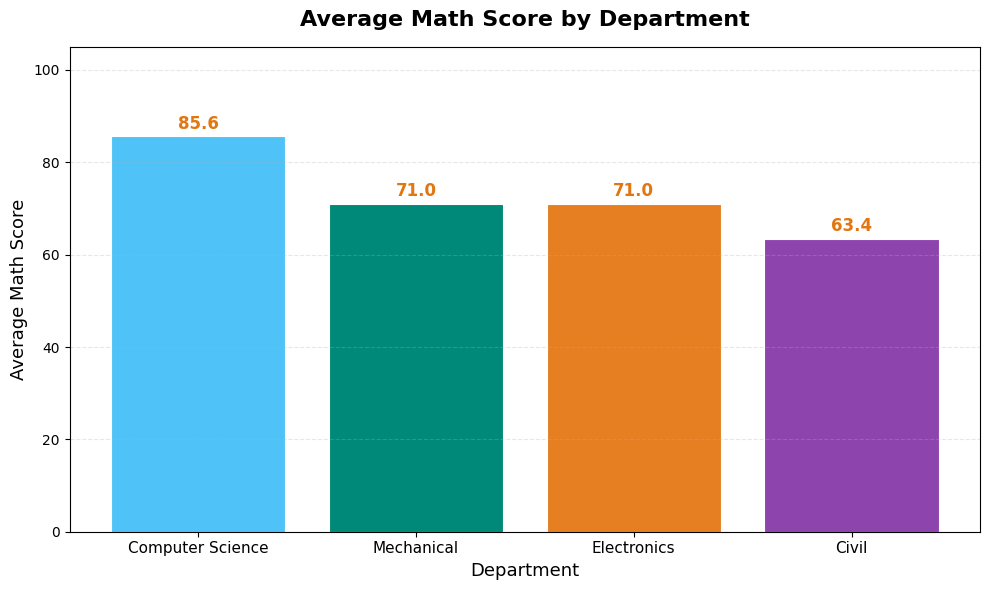

In [18]:
chart1_sql="""
  SELECT department,ROUND(AVG(math_score),2) AS  avg_math
  FROM students
  GROUP BY department
  ORDER BY avg_math DESC
  """
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['#4FC3F7','#008978','#E67E22','#8E44AD']
bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='#E27610'
  )
ax.set_title('Average Math Score by Department',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Department',fontsize=13)
ax.set_ylabel('Average Math Score',fontsize=13)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

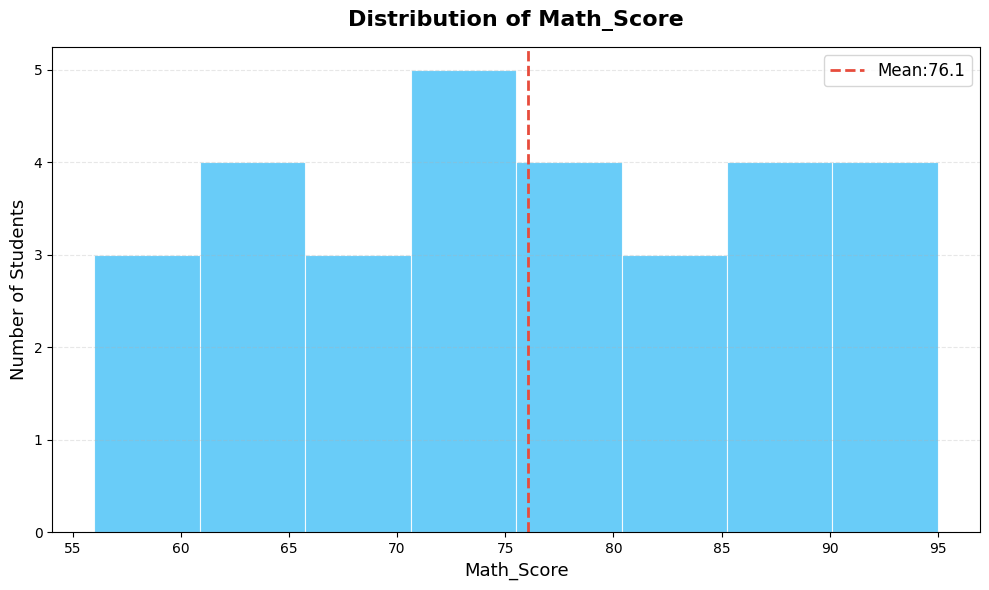

In [19]:
math_score=df['math_score'].tolist()
fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    math_score,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
mean_score=sum(math_score)/len(math_score)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean:{mean_score:.1f}'
)
ax.set_title('Distribution of Math_Score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Math_Score',fontsize=13)
ax.set_ylabel('Number of Students',fontsize=13)
ax.legend(fontsize=12)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
df=pd.DataFrame({
    'Category':np.random.choice(['A','B','C','D'],100),
    'Value':np.random.randint(10,100,100),
    'Score':np.random.randint(1,10,100)

})
df.head()

,Category,Value,Score
0,B,94,5
1,C,40,1
2,A,35,6
3,C,36,3
4,D,26,8


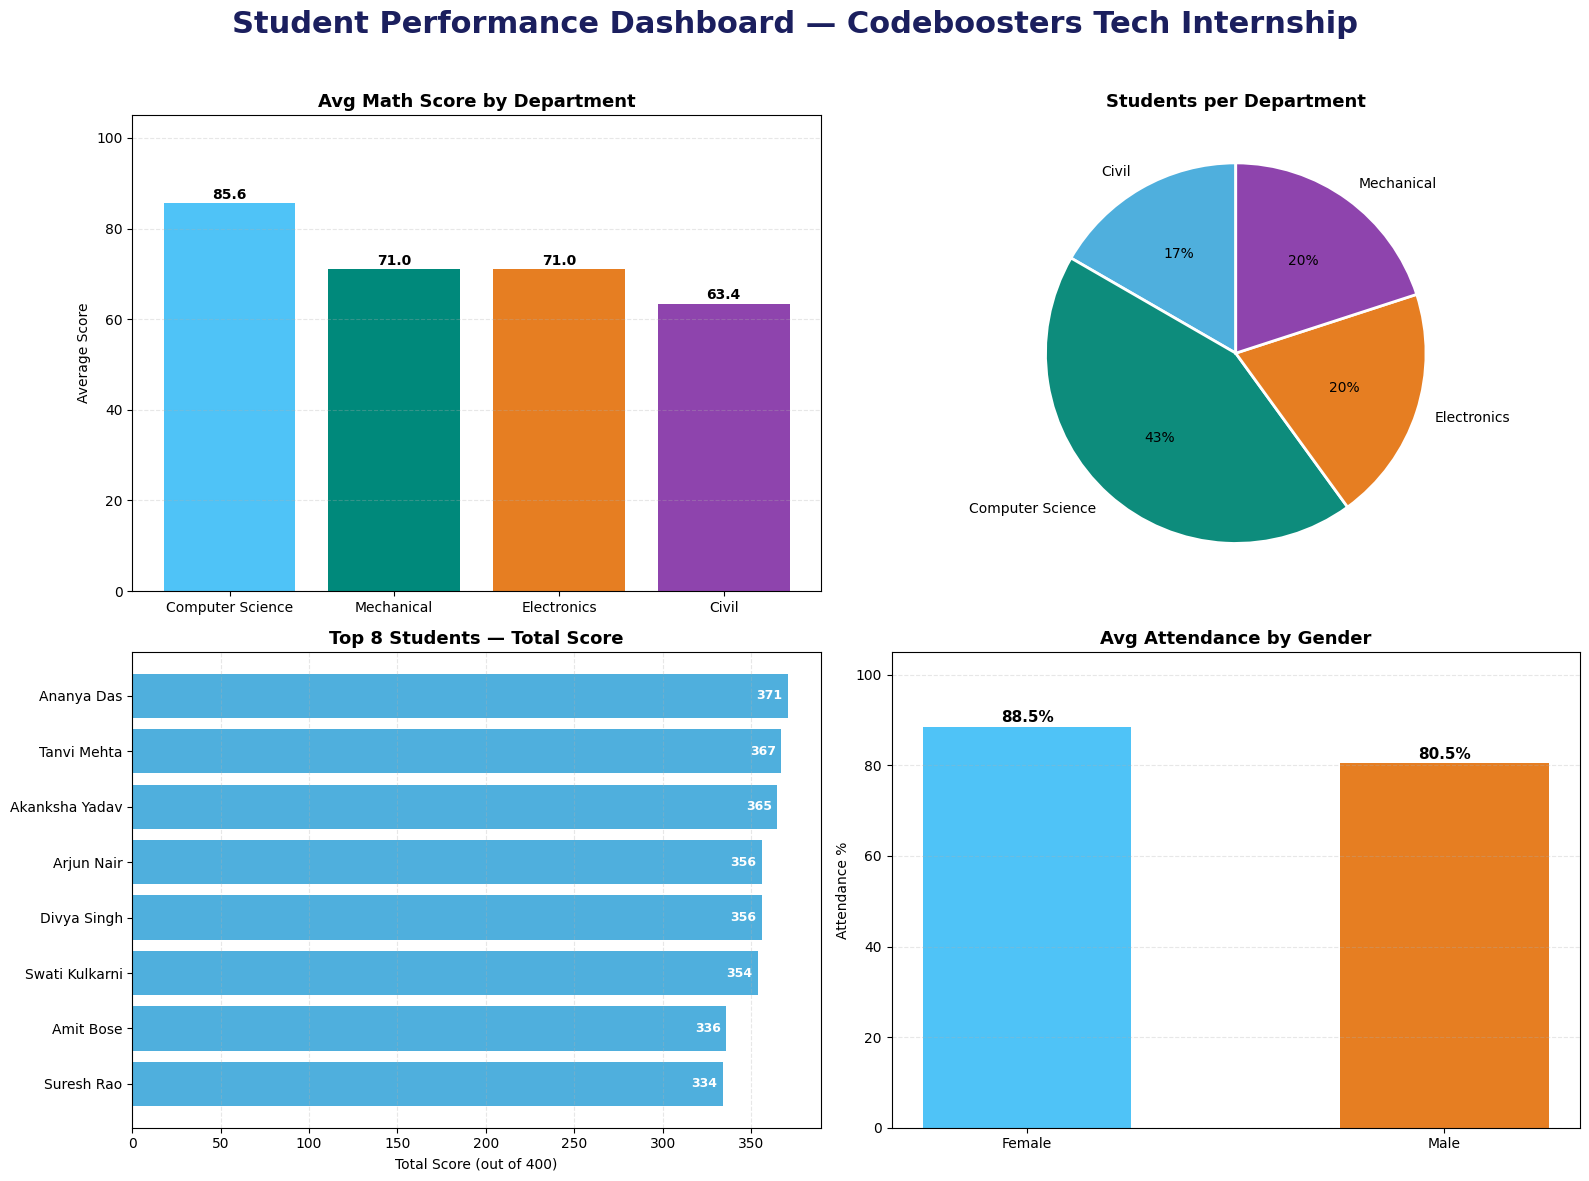

In [21]:
                                                      #TASK 2

# QUERY 1: AVG MATH SCORE BY DEPARTMENT


chart1_sql = """
SELECT department,
       ROUND(AVG(math_score), 1) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


# QUERY 2: STUDENT COUNT PER DEPARTMENT


chart2_sql = """
SELECT department,
       COUNT(*) AS total_students
FROM students
GROUP BY department
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)


# QUERY 3: TOP 8 STUDENTS BY TOTAL SCORE


chart3_sql = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

chart3_data = pd.read_sql_query(chart3_sql, conn)


# QUERY 4: AVG ATTENDANCE BY GENDER


chart4_sql = """
SELECT gender,
       ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY gender
"""

chart4_data = pd.read_sql_query(chart4_sql, conn)


# CREATE DASHBOARD


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PANEL 1 : AVG MATH SCORE BY DEPARTMENT


ax1 = axes[0, 0]

colors1 = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars1 = ax1.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=colors1
)

ax1.set_title("Avg Math Score by Department",
              fontsize=13,
              fontweight='bold')

ax1.set_ylabel("Average Score")
ax1.set_ylim(0, 105)


ax1.grid(axis='y', linestyle='--', alpha=0.3)


for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# PANEL 2 : PIE CHART


ax2 = axes[0, 1]

pie_colors = ['#4FAFDD', '#0D8C7C', '#E67E22', '#8E44AD']

ax2.pie(
    chart2_data['total_students'],
    labels=chart2_data['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=pie_colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

ax2.set_title("Students per Department",
              fontsize=13,
              fontweight='bold')


# PANEL 3 : TOP 8 STUDENTS


ax3 = axes[1, 0]

# Reverse order so topper appears at top
chart3_data = chart3_data[::-1]

bars3 = ax3.barh(
    chart3_data['name'],
    chart3_data['total_score'],
    color='#4FAFDD'
)

ax3.set_title("Top 8 Students — Total Score",
              fontsize=13,
              fontweight='bold')

ax3.set_xlabel("Total Score (out of 400)")

# Grid lines
ax3.grid(axis='x', linestyle='--', alpha=0.3)

# Score Labels Inside Bars
for bar in bars3:
    width = bar.get_width()
    ax3.text(
        width - 3,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        ha='right',
        color='white',
        fontsize=9,
        fontweight='bold'
    )


# PANEL 4 : ATTENDANCE BY GENDER


ax4 = axes[1, 1]

colors4 = ['#4FC3F7', '#E67E22']

bars4 = ax4.bar(
    chart4_data['gender'],
    chart4_data['avg_attendance'],
    color=colors4,
    width=0.5
)

ax4.set_title("Avg Attendance by Gender",
              fontsize=13,
              fontweight='bold')

ax4.set_ylabel("Attendance %")
ax4.set_ylim(0, 105)

# Grid lines
ax4.grid(axis='y', linestyle='--', alpha=0.3)

# Percentage Labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


# MAIN DASHBOARD TITLE


fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=22,
    fontweight='bold',
    color='#1B1F5E'
)


plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [22]:
query1 = """
SELECT ROUND(AVG(programming_score), 1) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

result1 = pd.read_sql_query(query1, conn)

print(result1)

   avg_programming_score
0                   70.2


In [23]:
query_where = """
SELECT name, math_score
FROM students
WHERE math_score > 80
"""

result_where = pd.read_sql_query(query_where, conn)

print(result_where)

              name  math_score
0     Aarav Sharma          85
1       Arjun Nair          92
2      Divya Singh          88
3       Ananya Das          95
4       Suresh Rao          83
5     Ritu Agarwal          87
6   Swati Kulkarni          90
7      Tanvi Mehta          93
8        Amit Bose          86
9    Gaurav Shukla          84
10  Akanksha Yadav          91


In [24]:
query3 = """
SELECT department,
       ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

result3 = pd.read_sql_query(query3, conn)

print(result3)

         department  avg_attendance
0  Computer Science            90.7


In [26]:
data = pd.read_sql_query(
    "SELECT * FROM students",
    conn
)

print(data)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

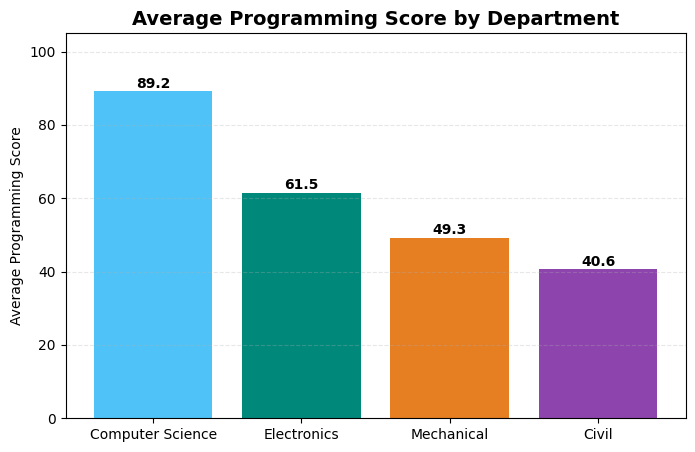

In [27]:
# =========================================
# AVG PROGRAMMING SCORE BY DEPARTMENT
# =========================================

chart1_sql = """
SELECT department,
       ROUND(AVG(programming_score), 1) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

# --------------------------------
# BAR CHART
# --------------------------------

plt.figure(figsize=(8, 5))

colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars = plt.bar(
    chart1_data['department'],
    chart1_data['avg_programming'],
    color=colors
)

plt.title(
    "Average Programming Score by Department",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Average Programming Score")

plt.ylim(0, 105)

# Grid lines
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()